In [30]:
from pinnsform.util import *
from pinnsform.model import PINN, FLS, FLW, FullWavelet
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
%matplotlib inline

def load_csv_to_numpy(file_path):
    df = pd.read_csv(file_path, header=None, index_col=None, sep=",")
    return np.array(df.values)

In [2]:
base_dir = os.getcwd()
experiment_name = "FourModels_TS_LBFGS_200"
data_path = os.path.join(base_dir, '..', 'results', experiment_name, 'run')

analysis_path = os.path.join(base_dir, 'analysis', experiment_name)

pinn_path = os.path.join(data_path, "PINN")
fls_path = os.path.join(data_path, "FLS")
flw_path = os.path.join(data_path, "FLW")
fullw_path = os.path.join(data_path, "FullWavelet")

In [16]:
device = 'cpu'

pinn = PINN(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

fls = FLS(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

flw = FLW(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

fullwavelet = FullWavelet(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

NUM_SEEDS = 100
INIT_SEEDS = np.array(range(NUM_SEEDS))

In [36]:
def visualize_mesh(mesh, mesh_shape, domain, norm = None, cmap = "viridis", scaling = (0.0, 1.0), file_name = 'analytic'):
    reshaped_mesh = np.reshape(mesh, mesh_shape)
    #[0,np.pi*2,1,0]
    plt.figure(figsize=(4,3))
    domain_extend = [domain[1][0], domain[1][1], domain[0][0], domain[0][1]]
    if scaling:
        plt.imshow(reshaped_mesh, norm = norm, cmap=cmap, extent=domain_extend, vmin=scaling[0], vmax=scaling[1], aspect='auto')
    else:
        plt.imshow(reshaped_mesh, norm = norm, cmap=cmap, extent=domain_extend, aspect='auto')
    plt.xlabel('t')
    plt.ylabel('x')
    #plt.title('u(x,t)')
    cb = plt.colorbar()
    cb.ax.set_yscale('linear')
    plt.tight_layout()
    plt.savefig('./plots/'+file_name+'.png', dpi=400)
    plt.show()

def get_solution_of_seed(model, path, seed, mesh):
    model.load_state_dict(torch.load(os.path.join(path, f"seed_{seed}", "model_at_200.pth")))
    return f(model, mesh).detach().numpy()


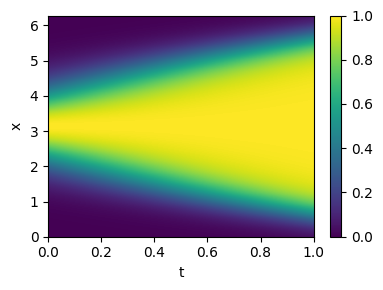

In [64]:
RHO = 5.0

def h(x):
    return np.exp( - (x-np.pi)**2 / (2 * (np.pi/4)**2))

def u_ana(x,t):
    return h(x) * np.exp(RHO*t) / ( h(x) * np.exp(RHO*t) + 1 - h(x))

problem_domain = ([0, 2*np.pi], [0, 1])

problem_name = "1Dreaction"

test_shape = (201, 201)
test_mesh, _ = generate_mesh_object(test_shape, domain=problem_domain, device=device, full_requires_grad=False, border_requires_grad=False)
analytic_solution = u_ana(test_mesh.part[0].cpu().numpy(), test_mesh.part[1].cpu().numpy())

visualize_mesh(analytic_solution, test_shape, problem_domain, file_name=f'{problem_name}_analytic')

In [54]:
pinn_good_bad = (10, 34)
fls_good_bad = (0, 39)
flw_good_bad = (97, 98)
fullw_good_bad = (97, 70)


def model_solution_diff_visualization(model, model_name, model_path, good_bad_indices):
    good_prediction = get_solution_of_seed(model, model_path, good_bad_indices[0], test_mesh)
    bad_prediction = get_solution_of_seed(model, model_path, good_bad_indices[1], test_mesh)
    good_diff = analytic_solution - good_prediction
    bad_diff = analytic_solution - bad_prediction
    
    visualize_mesh(good_diff, test_shape, problem_domain, norm = TwoSlopeNorm(0, -1, 1), cmap='twilight_shifted_r', scaling=None, file_name=f'{problem_name}_{model_name}_good({good_bad_indices[0]})_diff')
    visualize_mesh(bad_diff, test_shape, problem_domain, norm = TwoSlopeNorm(0, -1, 1), cmap='twilight_shifted_r', scaling=None, file_name=f'{problem_name}_{model_name}_bad({good_bad_indices[1]})_diff')
    visualize_mesh(good_prediction, test_shape, problem_domain, file_name=f'{problem_name}_{model_name}_good({good_bad_indices[0]})')
    visualize_mesh(bad_prediction, test_shape, problem_domain, file_name=f'{problem_name}_{model_name}_bad({good_bad_indices[1]})')

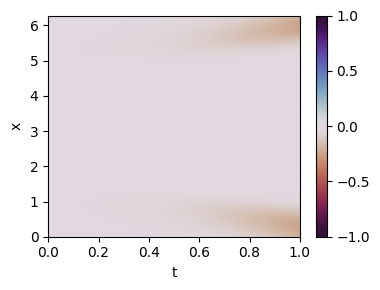

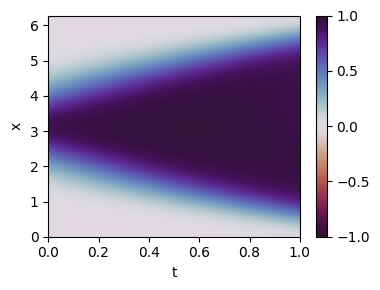

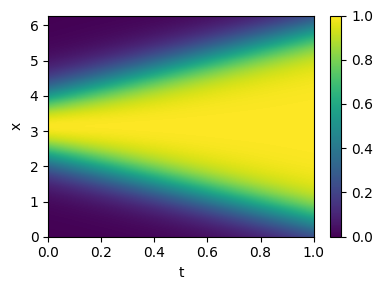

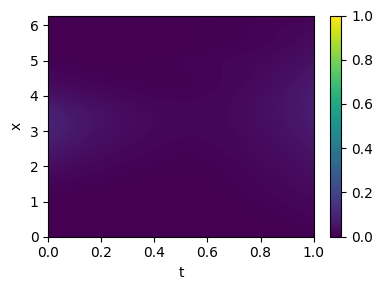

In [61]:
model_solution_diff_visualization(pinn, "PINN", pinn_path, pinn_good_bad)

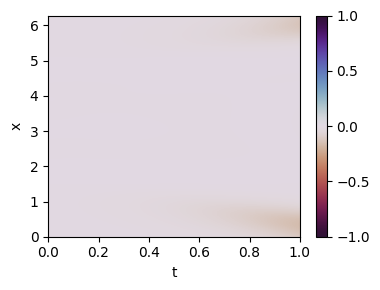

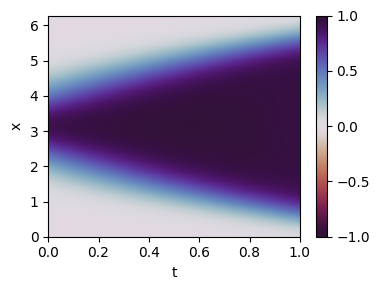

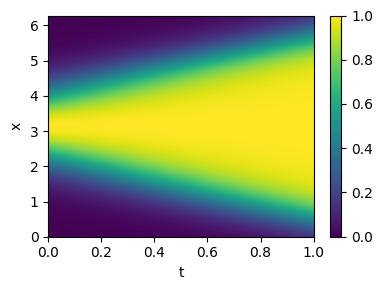

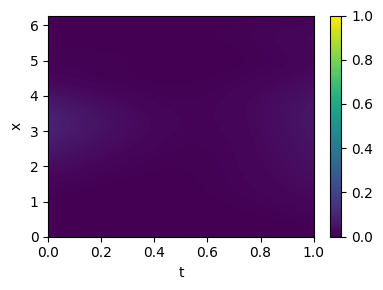

In [62]:
model_solution_diff_visualization(fls, "FLS", fls_path, fls_good_bad)

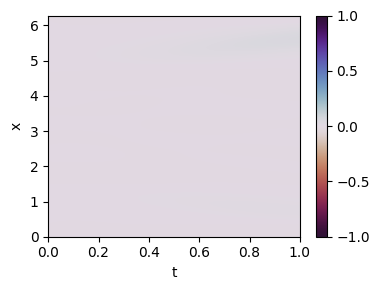

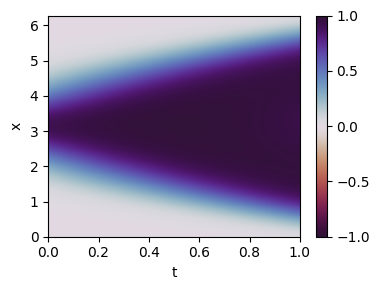

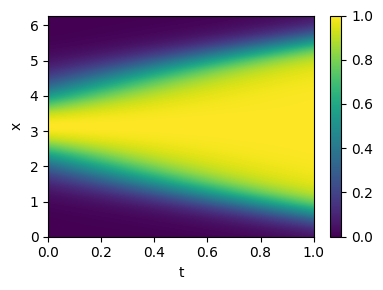

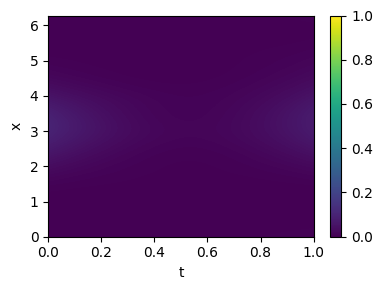

In [63]:
model_solution_diff_visualization(flw, "FLW", flw_path, flw_good_bad)

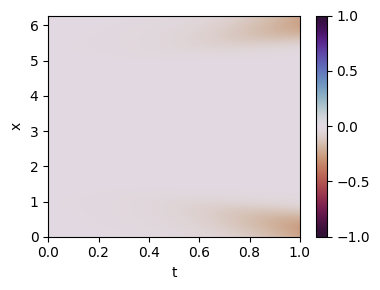

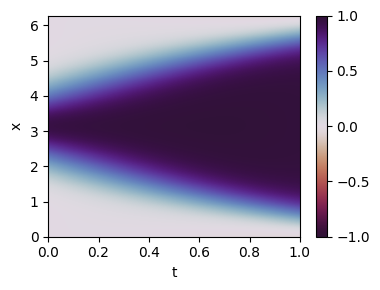

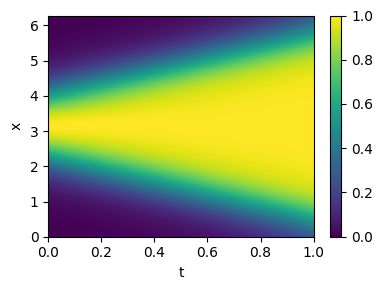

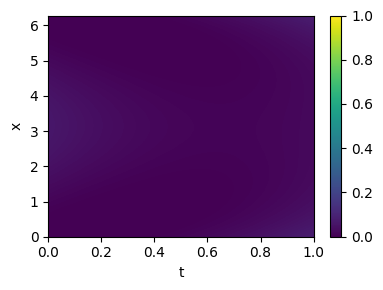

In [60]:
model_solution_diff_visualization(fullwavelet, "FullW", fullw_path, fullw_good_bad)

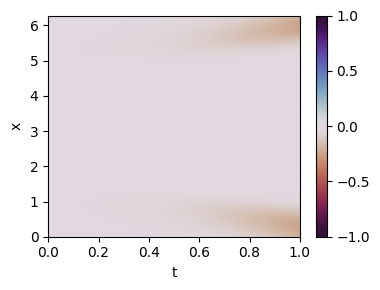

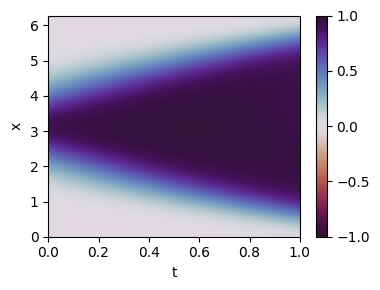

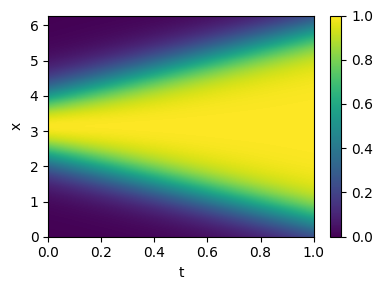

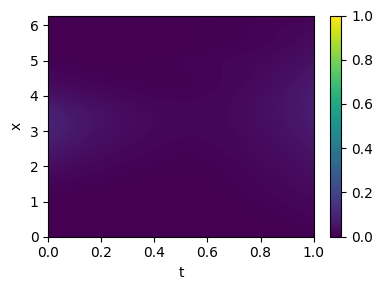

In [46]:
# PINN
good_prediction = get_solution_of_seed(pinn, pinn_path, pinn_good_bad[0], test_mesh)
bad_prediction = get_solution_of_seed(pinn, pinn_path, pinn_good_bad[1], test_mesh)
good_diff = analytic_solution - good_prediction
bad_diff = analytic_solution - bad_prediction
visualize_mesh(good_diff, test_shape, problem_domain, norm = TwoSlopeNorm(0, -1, 1), cmap='twilight_shifted_r', scaling=None, file_name=f'1Dreaction_PINN_good({pinn_good_bad[0]})_diff')
visualize_mesh(bad_diff, test_shape, problem_domain, norm = TwoSlopeNorm(0, -1, 1), cmap='twilight_shifted_r', scaling=None, file_name=f'1Dreaction_PINN_bad({pinn_good_bad[1]})_diff')

visualize_mesh(good_prediction, test_shape, problem_domain, file_name=f'1Dreaction_PINN_good({pinn_good_bad[0]})')
visualize_mesh(bad_prediction, test_shape, problem_domain, file_name=f'1Dreaction_PINN_bad({pinn_good_bad[1]})')

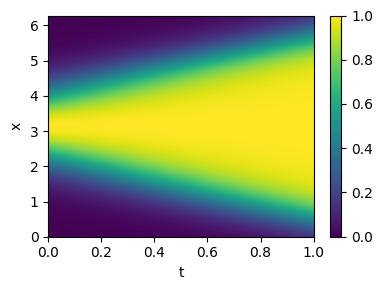

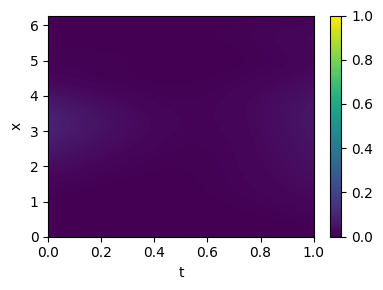

In [12]:
# FLS
good_prediction = get_solution_of_seed(fls, fls_path, fls_good_bad[0], test_mesh)
bad_prediction = get_solution_of_seed(fls, fls_path, fls_good_bad[1], test_mesh)

visualize_mesh(good_prediction, test_shape, problem_domain, file_name=f'1Dreaction_FLS_good({fls_good_bad[0]})')
visualize_mesh(bad_prediction, test_shape, problem_domain, file_name=f'1Dreaction_FLS_bad({fls_good_bad[1]})')

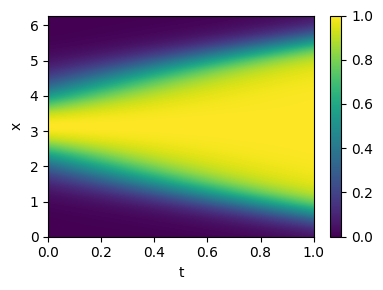

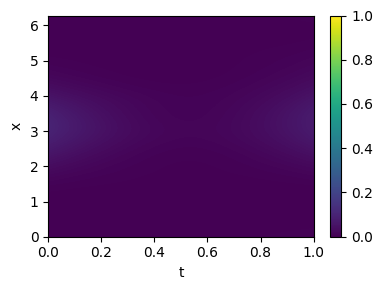

In [13]:
# FLW
good_prediction = get_solution_of_seed(flw, flw_path, flw_good_bad[0], test_mesh)
bad_prediction = get_solution_of_seed(flw, flw_path, flw_good_bad[1], test_mesh)

visualize_mesh(good_prediction, test_shape, problem_domain, file_name=f'1Dreaction_FLW_good({flw_good_bad[0]})')
visualize_mesh(bad_prediction, test_shape, problem_domain, file_name=f'1Dreaction_FLW_bad({flw_good_bad[1]})')

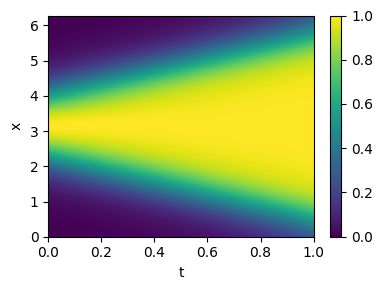

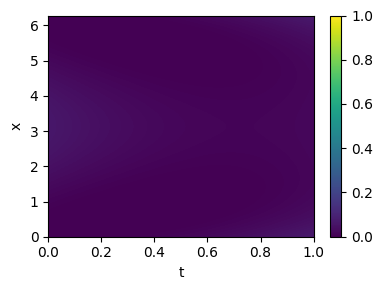

In [14]:
# FullW
fullw_good_bad = (97, 71)

good_prediction = get_solution_of_seed(fullwavelet, fullw_path, fullw_good_bad[0], test_mesh)
bad_prediction = get_solution_of_seed(fullwavelet, fullw_path, fullw_good_bad[1], test_mesh)

visualize_mesh(good_prediction, test_shape, problem_domain, file_name=f'1Dreaction_FullW_good({fullw_good_bad[0]})')
visualize_mesh(bad_prediction, test_shape, problem_domain, file_name=f'1Dreaction_FullW_bad({fullw_good_bad[1]})')